# MeAJOR Deep Learning Baselines

This notebook trains and evaluates two deep learning models, which are TextCNN and BiLSTM, on the processed MeAJOR dataset. Both models use a shared tokenisation pipeline and are evaluated using the same metrics schema as the classical baseline for direct comparison.

## 1. Import Libraries
All libraries needed for loading data, building and training deep learning models, and evaluating and saving results are imported here.

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd

# Keras utilities for building and training deep learning models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Bidirectional, LSTM, Dense, Dropout, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping

# Metrics for evaluating model performance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

## 2. Load Processed Data
The train and test Parquet files produced by `meajor_preparation.ipynb` are loaded here. These contain the cleaned `text` and `label` columns only.

In [2]:
# Path to the folder containing the processed MeAJOR parquet files
data_dir = Path("../data/processed/meajor/")

# Load the 60% training split
train_df = pd.read_parquet(data_dir / "meajor_train_60.parquet")

# Load the 40% test split
test_df = pd.read_parquet(data_dir / "meajor_test_40.parquet")

print(f"Train size: {len(train_df)} rows")
print(f"Test size:  {len(test_df)} rows")
print(f"Columns: {train_df.columns.tolist()}")

Train size: 62743 rows
Test size:  41829 rows
Columns: ['text', 'label']


## 3. Verify Loaded Data
A quick check to confirm the data loaded correctly, the label distribution is preserved, and sample rows look as expected before modelling begins.

In [3]:
# Preview the first 3 rows to confirm structure looks correct
print(train_df.head(3))
print()

# Confirm label balance matches the full dataset
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

                                                text  label
0  Subject: OVER [FINANCIAL_INFO] Body: HAS ANY O...      0
1  Subject: Or each ellenton Body: THE ALERT IS O...      1
2  Subject: Best place to find cure for your dise...      1

Train label distribution:
label
0    34768
1    27975
Name: count, dtype: int64

Test label distribution:
label
0    23179
1    18650
Name: count, dtype: int64


## 4. Prepare Features and Labels
The text (features) and label (target) are separated for both splits and checked for null values before tokenisation.

In [4]:
# Separate text and labels for training
X_train = train_df["text"].astype(str)
y_train = train_df["label"].values

# Separate text and labels for testing
X_test = test_df["text"].astype(str)
y_test = test_df["label"].values

# Confirm no null values remain in either split
print(f"Null values in X_train: {train_df['text'].isna().sum()}")
print(f"Null values in X_test:  {test_df['text'].isna().sum()}")
print(f"X_train: {len(X_train)} samples")
print(f"X_test:  {len(X_test)} samples")

Null values in X_train: 0
Null values in X_test:  0
X_train: 62743 samples
X_test:  41829 samples


## 5. Tokenisation and Padding
Each email's text is converted into a sequence of integers using Keras's Tokeniser, then padded to a fixed length so every input to the model is the same size.

In [5]:
# Maximum number of unique words to keep in the vocabulary
VOCAB_SIZE = 50000

# Maximum number of tokens per email — emails longer than this are truncated
MAX_LEN = 512

# Fit the tokeniser on training text only to prevent data leakage
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Convert text to integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad sequences so all inputs are the same length
# post padding adds zeros at the end of shorter sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

print(f"Training matrix shape: {X_train_pad.shape}")
print(f"Test matrix shape:     {X_test_pad.shape}")

Training matrix shape: (62743, 512)
Test matrix shape:     (41829, 512)


## 6. Build TextCNN Model
A Convolutional Neural Network is defined that applies filters of different sizes across the token sequence to detect local phishing-indicative phrases.

In [6]:
# Dimension of the dense vector representing each token
EMBEDDING_DIM = 128

def build_textcnn(vocab_size, embedding_dim, max_len):
    inputs = Input(shape=(max_len,))

    # Embedding layer converts token integers into dense vectors
    x = Embedding(vocab_size, embedding_dim)(inputs)

    # Three parallel convolution filters of different sizes to capture different phrase lengths
    conv3 = Conv1D(128, kernel_size=3, activation="relu")(x)
    conv4 = Conv1D(128, kernel_size=4, activation="relu")(x)
    conv5 = Conv1D(128, kernel_size=5, activation="relu")(x)

    # GlobalMaxPooling picks the most important feature from each filter
    pool3 = GlobalMaxPooling1D()(conv3)
    pool4 = GlobalMaxPooling1D()(conv4)
    pool5 = GlobalMaxPooling1D()(conv5)

    # Concatenate the three pooled outputs into one feature vector
    concat = Concatenate()([pool3, pool4, pool5])

    # Dropout randomly disables neurons during training to prevent overfitting
    dropped = Dropout(0.5)(concat)

    # Final output layer with sigmoid activation for binary classification
    outputs = Dense(1, activation="sigmoid")(dropped)

    model = Model(inputs, outputs)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

textcnn_model = build_textcnn(VOCAB_SIZE, EMBEDDING_DIM, MAX_LEN)
textcnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 512, 128)  │  6,400,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 510, 128)  │     49,280 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 509, 128)  │     65,664 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 508, 128)  │     82,048 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │        385 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,597,377 (25.17 MB)

 Trainable params: 6,597,377 (25.17 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train TextCNN
The TextCNN model is trained for up to 10 epochs with early stopping to prevent overfitting. A validation split is used to monitor performance during training.

In [7]:
# Early stopping halts training if validation loss stops improving for 3 consecutive epochs
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

# Train the model using 10% of training data as a validation set
textcnn_history = textcnn_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 78s 88ms/step - accuracy: 0.8939 - loss: 0.2349 - val_accuracy: 0.9801 - val_loss: 0.0583
Epoch 2/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 76s 86ms/step - accuracy: 0.9885 - loss: 0.0346 - val_accuracy: 0.9820 - val_loss: 0.0514
Epoch 3/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 79s 89ms/step - accuracy: 0.9963 - loss: 0.0126 - val_accuracy: 0.9839 - val_loss: 0.0533
Epoch 4/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 81s 92ms/step - accuracy: 0.9980 - loss: 0.0073 - val_accuracy: 0.9822 - val_loss: 0.0650
Epoch 5/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 86s 97ms/step - accuracy: 0.9987 - loss: 0.0047 - val_accuracy: 0.9834 - val_loss: 0.0690


## 8. Evaluate TextCNN
The trained TextCNN is evaluated on the held-out test set. The classification report, confusion matrix figure, and metrics are saved.

1308/1308 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step
TextCNN Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       0.99      0.99      0.99     23179
  Phishing (1)       0.98      0.98      0.98     18650

      accuracy                           0.98     41829
     macro avg       0.98      0.98      0.98     41829
  weighted avg       0.98      0.98      0.98     41829



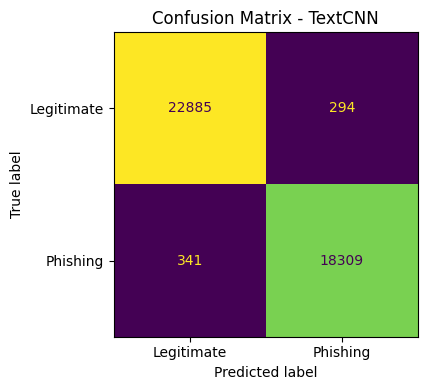

In [8]:
# Create the figures folder if it does not already exist
figures_dir = Path("../results/figures/")
figures_dir.mkdir(parents=True, exist_ok=True)

# Convert predicted probabilities to binary labels using 0.5 as the threshold
textcnn_probs = textcnn_model.predict(X_test_pad)
textcnn_pred = (textcnn_probs >= 0.5).astype(int).flatten()

print("TextCNN Classification Report:")
print(classification_report(y_test, textcnn_pred, target_names=["Legitimate (0)", "Phishing (1)"]))

# Build and save the confusion matrix figure
cm = confusion_matrix(y_test, textcnn_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Phishing"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix - TextCNN")
plt.tight_layout()
plt.savefig(figures_dir / "meajor_cm_textcnn.png", dpi=150)
plt.show()

## 9. Build BiLSTM Model
A Bidirectional LSTM is defined that reads each email sequence both forwards and backwards, capturing long-range contextual patterns that CNN filters may miss.

In [9]:
def build_bilstm(vocab_size, embedding_dim, max_len):
    inputs = Input(shape=(max_len,))

    # Embedding layer converts token integers into dense vectors
    x = Embedding(vocab_size, embedding_dim)(inputs)

    # Dropout applied to embeddings before the LSTM to reduce overfitting
    x = Dropout(0.3)(x)

    # Bidirectional LSTM reads the sequence in both directions and concatenates the outputs
    x = Bidirectional(LSTM(128, return_sequences=False))(x)

    # Dropout applied after the LSTM layer
    x = Dropout(0.5)(x)

    # Dense hidden layer to learn higher level features
    x = Dense(64, activation="relu")(x)

    # Final output layer with sigmoid activation for binary classification
    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

bilstm_model = build_bilstm(VOCAB_SIZE, EMBEDDING_DIM, MAX_LEN)
bilstm_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 512, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,679,681 (25.48 MB)

 Trainable params: 6,679,681 (25.48 MB)

 Non-trainable params: 0 (0.00 B)

## 10. Train BiLSTM
The BiLSTM model is trained for up to 10 epochs with early stopping, using the same training configuration as TextCNN for fair comparison.

In [10]:
# Reuse the same early stopping configuration as TextCNN for fair comparison
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

# Train the BiLSTM model with identical settings to TextCNN
bilstm_history = bilstm_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 704s 797ms/step - accuracy: 0.9143 - loss: 0.1973 - val_accuracy: 0.9764 - val_loss: 0.0681
Epoch 2/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 705s 799ms/step - accuracy: 0.9856 - loss: 0.0444 - val_accuracy: 0.9734 - val_loss: 0.0787
Epoch 3/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 703s 796ms/step - accuracy: 0.9915 - loss: 0.0264 - val_accuracy: 0.9763 - val_loss: 0.0737
Epoch 4/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 700s 792ms/step - accuracy: 0.9947 - loss: 0.0168 - val_accuracy: 0.9756 - val_loss: 0.0907


## 11. Evaluate BiLSTM
The trained BiLSTM is evaluated on the held-out test set. The classification report, confusion matrix figure, and metrics are saved.

1308/1308 ━━━━━━━━━━━━━━━━━━━━ 177s 136ms/step
BiLSTM Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       0.98      0.98      0.98     23179
  Phishing (1)       0.97      0.97      0.97     18650

      accuracy                           0.97     41829
     macro avg       0.97      0.97      0.97     41829
  weighted avg       0.97      0.97      0.97     41829



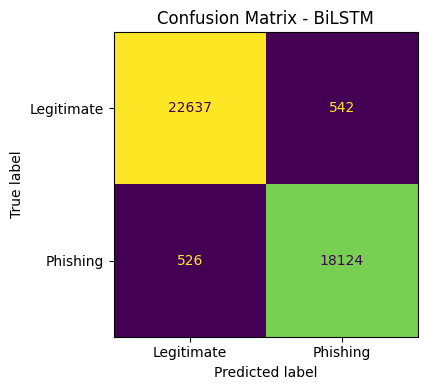

In [11]:
# Convert predicted probabilities to binary labels using 0.5 as the threshold
bilstm_probs = bilstm_model.predict(X_test_pad)
bilstm_pred = (bilstm_probs >= 0.5).astype(int).flatten()

print("BiLSTM Classification Report:")
print(classification_report(y_test, bilstm_pred, target_names=["Legitimate (0)", "Phishing (1)"]))

# Build and save the confusion matrix figure
cm = confusion_matrix(y_test, bilstm_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Phishing"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix - BiLSTM")
plt.tight_layout()
plt.savefig(figures_dir / "meajor_cm_bilstm.png", dpi=150)
plt.show()

## 12. Training Curves
The training and validation loss and accuracy over epochs are plotted for both models to visualise learning behaviour and check for overfitting.

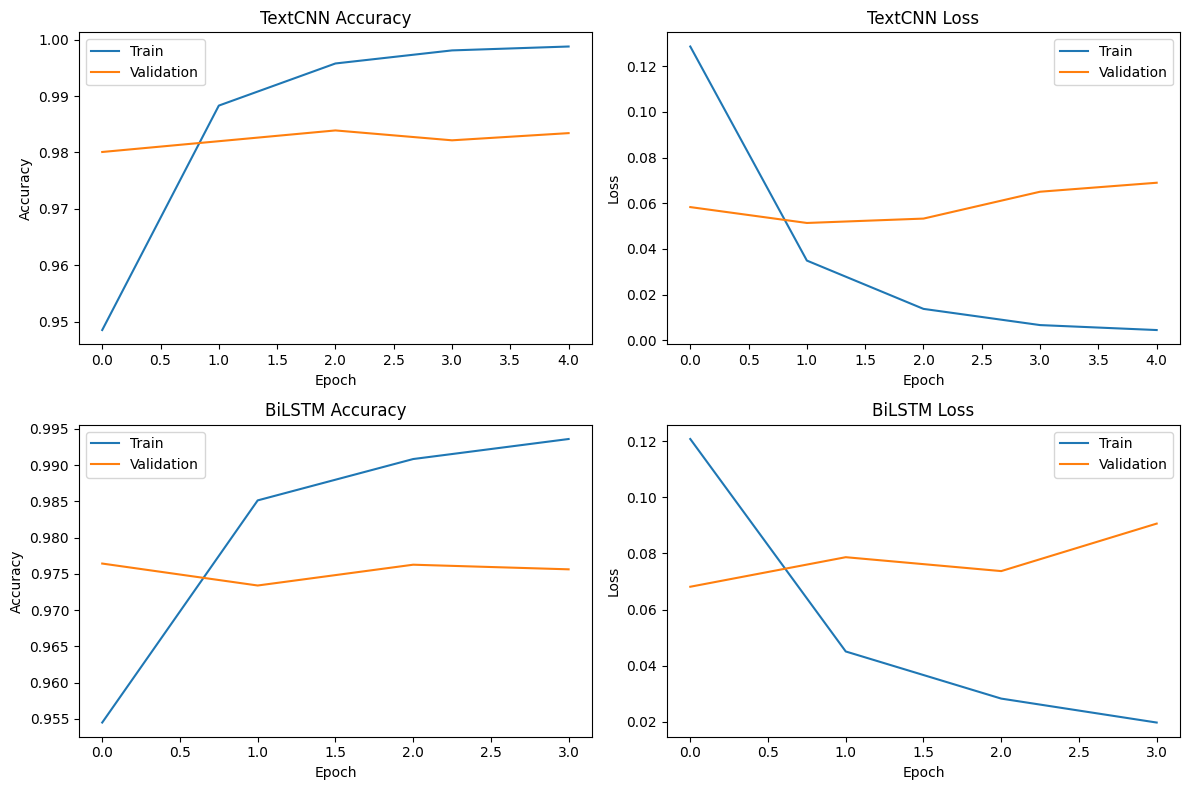

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# TextCNN training and validation accuracy over epochs
axes[0, 0].plot(textcnn_history.history["accuracy"], label="Train")
axes[0, 0].plot(textcnn_history.history["val_accuracy"], label="Validation")
axes[0, 0].set_title("TextCNN Accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].legend()

# TextCNN training and validation loss over epochs
axes[0, 1].plot(textcnn_history.history["loss"], label="Train")
axes[0, 1].plot(textcnn_history.history["val_loss"], label="Validation")
axes[0, 1].set_title("TextCNN Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()

# BiLSTM training and validation accuracy over epochs
axes[1, 0].plot(bilstm_history.history["accuracy"], label="Train")
axes[1, 0].plot(bilstm_history.history["val_accuracy"], label="Validation")
axes[1, 0].set_title("BiLSTM Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].legend()

# BiLSTM training and validation loss over epochs
axes[1, 1].plot(bilstm_history.history["loss"], label="Train")
axes[1, 1].plot(bilstm_history.history["val_loss"], label="Validation")
axes[1, 1].set_title("BiLSTM Loss")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(figures_dir / "meajor_dl_training_curves.png", dpi=150)
plt.show()

## 13. Results Summary
The evaluation metrics for both models are compiled into a single CSV file matching the classical baseline schema for direct comparison.

In [13]:
metrics_dir = Path("../results/metrics/")
metrics_dir.mkdir(parents=True, exist_ok=True)

summary_rows = []

for name, model, y_pred, probs in [
    ("TextCNN", textcnn_model, textcnn_pred, textcnn_probs),
    ("BiLSTM",  bilstm_model,  bilstm_pred,  bilstm_probs),
]:
    # Time inference on the test set
    start = time.time()
    model.predict(X_test_pad, verbose=0)
    elapsed = time.time() - start

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # False positive rate is legitimate emails wrongly predicted as phishing
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    summary_rows.append({
        "dataset": "MeAJOR",
        "model": name,
        "accuracy": round(accuracy_score(y_test, y_pred), 6),
        "precision": round(precision_score(y_test, y_pred, pos_label=1), 6),
        "recall": round(recall_score(y_test, y_pred, pos_label=1), 6),
        "f1": round(f1_score(y_test, y_pred, pos_label=1), 6),
        "false_positive_rate": round(fpr, 6),
        "inference_time_total_sec": round(elapsed, 6),
        "inference_time_per_email_sec": round(elapsed / len(y_test), 9),
        "train_rows": len(y_train),
        "test_rows": len(y_test),
        "vocab_size": VOCAB_SIZE,
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string())

summary_df.to_csv(metrics_dir / "meajor_dl_baseline_results.csv", index=False)
print("\nResults saved to ../results/metrics/meajor_dl_baseline_results.csv")

  dataset    model  accuracy  precision    recall        f1  false_positive_rate  inference_time_total_sec  inference_time_per_email_sec  train_rows  test_rows  vocab_size
0  MeAJOR  TextCNN  0.984819   0.984196  0.981716  0.982954             0.012684                 17.199174                      0.000411       62743      41829       50000
1  MeAJOR   BiLSTM  0.974467   0.970963  0.971796  0.971380             0.023383                167.715403                      0.004010       62743      41829       50000

Results saved to ../results/metrics/meajor_dl_baseline_results.csv
